# Lista 2 - MLP, CNN, GAN, GNN
**Aluno:** Vitor Fontenele de Oliveira Linhares

**Mátricula:** 1700778

## Setup

In [7]:

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST, MNIST
from torchvision.utils import make_grid
from ucimlrepo import fetch_ucirepo
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Questão 1: MLP - Breast Cancer Wisconsin

### 1.1 Descrição e entendimento do problema

O dataset reúne atributos numéricos extraídos de imagens de núcleos de células, e tentaremos prever o diagnóstico entre benigno e maligno. Inicialmente, faremos um EDA para entender o formato do dataset, observar o comportamento das variáveis e verificar se existem sinais de desbalanceamento na distribuição das classes target, além de correlações relevantes (que não sejam na diagonal principal da matriz de correlação).

Diagnosis
B    357
M    212
Name: count, dtype: int64

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis_Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


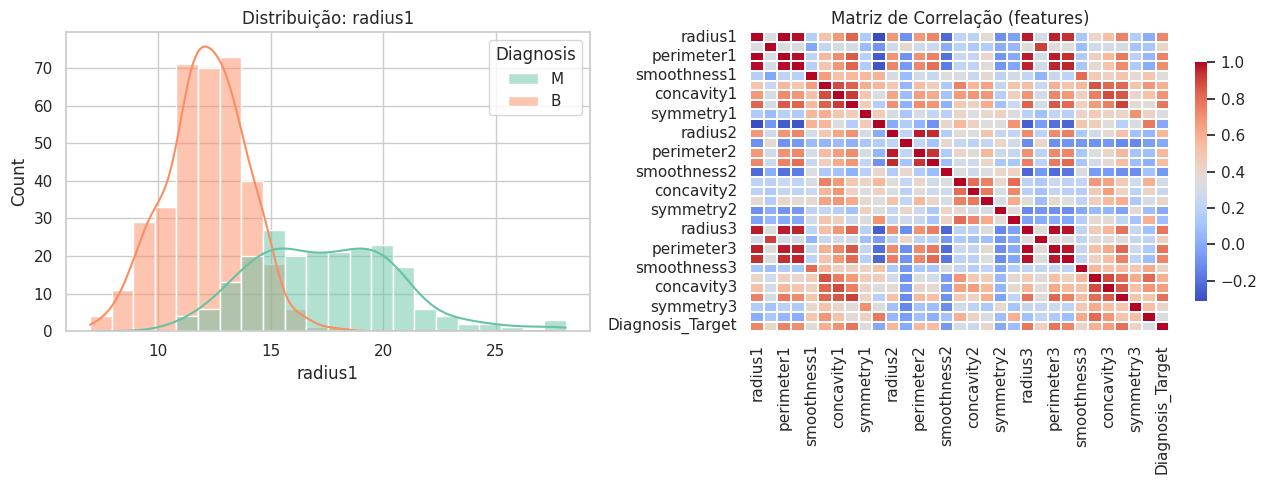

In [5]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

target_col = y['Diagnosis']
display(target_col.value_counts())
target_numeric = target_col.map({'B': 0, 'M': 1})

df = pd.concat([X, target_numeric.rename('Diagnosis_Target')], axis=1)
display(df.head())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

first_feat = X.columns[0]
sns.histplot(data=df, x=first_feat, hue=target_col, kde=True, palette='Set2', ax=axes[0])
axes[0].set_title(f'Distribuição: {first_feat}')
axes[0].set_xlabel(first_feat)

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.2, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlação (features)')

plt.tight_layout()
plt.show()

Na exploração inicial, percebemos alguns pontos importantes. A base tem muitas variáveis com comportamento e nome parecido (e.g., `radius1`, `radius2`, `radius3`), o que indica potencial correlação entre algumas features, e a matriz de correlação confirma isso com pares significativos fora da diagonal principal. Também olhamos o balanceamento do target, porque em problema médico tabular é possível que venha desbalanceado. É notável que existe diferença, mas não é extrema (**357** benignos e **212** malignos). No fim, o problema realmente parece se caracterizar e se adequar como classificação supervisionada em dados tabulares, com alvo binário. 

### 1.2 Preparação dos Dados

Neste momento, definiremos uma função para reduzir dimensões avaliando a potencial correlação percebida anteriormente, depois faremos o split em treino, validação e teste e chamamos a função para reduzir as dimensões. 

In [6]:
def fit_corr_feature_selector(X_train_df, threshold=0.95):
    feature_cols = X_train_df.columns.tolist()

    corr_feat = X_train_df.corr().abs()
    upper_feat = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))

    high_pairs_095 = (
        upper_feat.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr_abs'})
    )
    high_pairs_095 = high_pairs_095[high_pairs_095['corr_abs'] >= threshold].reset_index(drop=True)

    adj = {f: set() for f in feature_cols}
    for _, row in high_pairs_095.iterrows():
        a = row['feature_1']
        b = row['feature_2']
        adj[a].add(b)
        adj[b].add(a)

    visited = set()
    components = []
    for f in feature_cols:
        if f in visited:
            continue
        stack = [f]
        comp = set()
        while stack:
            node = stack.pop()
            if node in visited:
                continue
            visited.add(node)
            comp.add(node)
            stack.extend(adj[node] - visited)
        components.append(comp)

    keep_features = [sorted(comp)[0] for comp in components]
    return sorted(keep_features), high_pairs_095

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, target_numeric, test_size=0.15, random_state=42, stratify=target_numeric
)

val_ratio_adjusted = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, random_state=42, stratify=y_temp
)

print(f'Features antes da redução (treino): {X_train.shape[1]}')

keep_features, high_pairs_095 = fit_corr_feature_selector(X_train, threshold=0.95)

X_train = X_train[keep_features].copy()
X_val = X_val[keep_features].copy()
X_test = X_test[keep_features].copy()

print(f'Features após redução (fit no treino): {len(keep_features)}')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'Shapes -> treino: {X_train.shape}, validação: {X_val.shape}, teste: {X_test.shape}')

Features antes da redução (treino): 30
Features após redução (fit no treino): 23
Shapes -> treino: (397, 23), validação: (86, 23), teste: (86, 23)


### 1.3 Configuração + Treinamento + Validação

Nesta etapa comparamos duas configurações de MLP. Em cada época calculamos métricas de treino e de validação, e escolhemos o melhor estado do modelo com base na perda de validação. Separamos definição do modelo/funções e execução do treino + validação.

In [19]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

input_dim = X_train.shape[1]
num_classes = 2

train_params = {
    'epochs': 20,
    'batch_size': 32,
    'learning_rate': 1e-3,
}

mlp_configs = {
    'Config A': {
        'hidden_dims': [2],
        'dropout': 0.1,
        'weight_decay': 0.0,
    },
    'Config B': {
        'hidden_dims': [16, 8],
        'dropout': 0.2,
        'weight_decay': 1e-3,
    }
}

print(f"Input dim: {input_dim} | Classes: {num_classes}")
print("Parâmetros de treino:")
display(pd.DataFrame([train_params]))

print("Configurações comparadas:")
display(pd.DataFrame(mlp_configs).T)

Input dim: 23 | Classes: 2
Parâmetros de treino:


,epochs,batch_size,learning_rate
0,20,32,0.001


Configurações comparadas:


,hidden_dims,dropout,weight_decay
Config A,[2],0.1,0.0
Config B,"[16, 8]",0.2,0.001


In [20]:
class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.0, num_classes=2):
        super().__init__()
        layers = []
        prev = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=train_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=train_params['batch_size'], shuffle=False)


def train_mlp_model(_, config):
    model = MLPModel(
        input_dim=input_dim,
        hidden_dims=config['hidden_dims'],
        dropout=config['dropout'],
        num_classes=num_classes,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=train_params['learning_rate'],
        weight_decay=config['weight_decay']
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    best_state = None

    for _ in range(train_params['epochs']):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * yb.size(0)
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss_sum += loss.item() * yb.size(0)
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        epoch_train_loss = train_loss_sum / train_total
        epoch_val_loss = val_loss_sum / val_total
        epoch_train_acc = train_correct / train_total
        epoch_val_acc = val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history, best_val_loss

,config,best_val_loss
0,Config B,0.074394
1,Config A,0.241017


Melhor configuração na validação: Config B


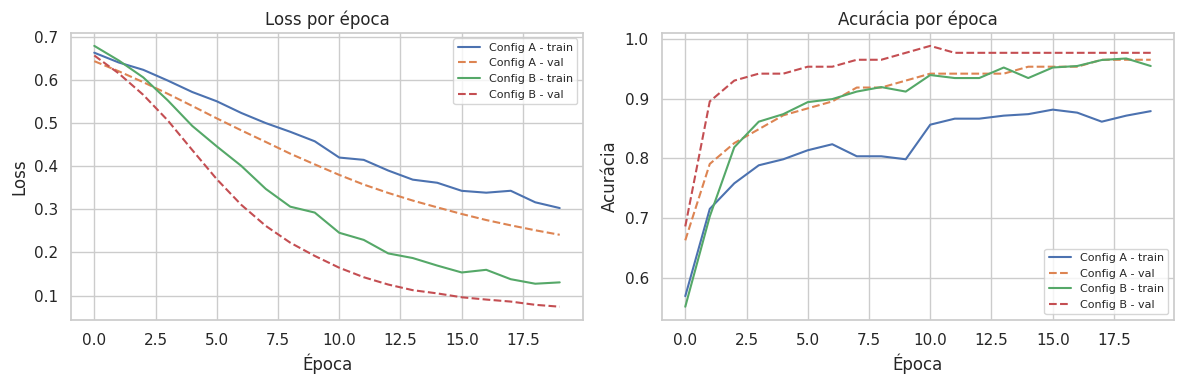

In [22]:
mlp_runs = {}
for cfg_name, cfg in mlp_configs.items():
    model, history, best_val = train_mlp_model(cfg_name, cfg)
    mlp_runs[cfg_name] = {
        'model': model,
        'history': history,
        'best_val_loss': best_val,
    }

resumo_validacao = pd.DataFrame([
    {'config': name, 'best_val_loss': run['best_val_loss']}
    for name, run in mlp_runs.items()
]).sort_values('best_val_loss').reset_index(drop=True)

mlp_best_name = resumo_validacao.loc[0, 'config']
mlp_best_model = mlp_runs[mlp_best_name]['model']

display(resumo_validacao)
print(f"Melhor configuração na validação: {mlp_best_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cfg_name, run in mlp_runs.items():
    axes[0].plot(run['history']['train_loss'], label=f"{cfg_name} - train")
    axes[0].plot(run['history']['val_loss'], linestyle='--', label=f"{cfg_name} - val")

axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

for cfg_name, run in mlp_runs.items():
    axes[1].plot(run['history']['train_acc'], label=f"{cfg_name} - train")
    axes[1].plot(run['history']['val_acc'], linestyle='--', label=f"{cfg_name} - val")

axes[1].set_title('Acurácia por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 1.4 Métricas
*Acurácia, Precisão, Recall, F1 e Matriz de Confusão.*


In [23]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_np = y_test.values

results = []
conf_mats = {}

for cfg_name, run in mlp_runs.items():
    model = run['model']
    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

    acc = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_test_np, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test_np, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_test_np, y_pred)

    results.append({
        'config': cfg_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
    })
    conf_mats[cfg_name] = cm

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
results_df_fmt = results_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1']:
    results_df_fmt[col] = results_df_fmt[col].map(lambda x: f"{x:.4f}")

print('Resumo de métricas no teste:')
display(results_df_fmt)

print('Matrizes de confusão (tabelas):')
for cfg_name, cm in conf_mats.items():
    print(f"\n{cfg_name}")
    display(pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))

Resumo de métricas no teste:


,config,accuracy,precision,recall,f1
0,Config B,1.0000,1.0000,1.0000,1.0000
1,Config A,0.9651,0.9677,0.9375,0.9524


Matrizes de confusão (tabelas):

Config A


,Pred 0,Pred 1
Real 0,53,1
Real 1,2,30



Config B


,Pred 0,Pred 1
Real 0,54,0
Real 1,0,32


### 1.5 Análise

Pelos resultados, as duas configurações tiveram desempenho aceitável, com vantagem clara da Configuração B. Na validação, ela ficou com menor perda (`best_val_loss = 0.0743` contra `0.2410` da Config A), e no teste também terminou melhor, atingindo desempenho máximo (`accuracy = 1.0000` e `f1 = 1.0000`, contra `0.9651` e `0.9524` da Config A). A Configuração B obteve acurácia ideal na base de teste, confirmando a robustez da arquitetura mais profunda para o problema.

Também é importante considerar o tamanho do dataset. A entrada é pequena e, depois da divisão, a validação fica menor ainda. Nesse contexto, com um ajuste razoável de arquitetura e regularização, o modelo tende a errar pouco porque há menos casos e o padrão do problema é mais direto. Além disso, a redução de features provavelmente ajudou a diminuir ruído e facilitou a convergência da rede.

Embora os resultados da Configuração B possam parecer perfeitos demais à primeira vista, eles potencialmente são explicados ao fazer uma análise da natureza do problema e do dataset. Como as características das células malignas diferem bastante das benignas, a separação das classes acaba sendo relativamente direta. Essa distinção clara, somada ao tamanho reduzido do conjunto de teste, permitiu que a rede encontrasse a fronteira de decisão ideal sem dificuldades.

Uma MLP é uma escolha válida nesse problema porque o dado é tabular, numérico e não tem dados faltantes (conforme indicado na documentação do [dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)). Não há estrutura espacial de imagem nem relação de grafos para justificar outro tipo de arquitetura (CNN, GAN e/ou GNN).

Por fim, em problema de diagnóstico não devemos olhar apenas para a acurácia. Neste caso, não há uma distribuição extremamente desigual, a validação inicial foi feita justamente pensando nesse tipo de risco, que é uma possibilidade real em datasets de dados tabulares. A análise detalhada das matrizes de confusão revelou que a Configuração A apresentou 2 casos de falsos negativos (amostras reais malignas classificadas como benignas), o que representa o cenário de maior risco em um contexto médico. Por isso, além da acurácia, a avaliação com precisão, recall, F1 e matriz de confusão é necessária para enxergar melhor o risco real dos erros.

---
## Questão 2: CNN - Fashion-MNIST


### 2.1 Descrição e entendimento do problema

O dataset do [Fashion-MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist/data) reúne imagens (matrizes de pixels) de roupas, com um target (a classe da peça de roupa). Novamente, faremos uma análise inicial do dataset (aliado a exploração de sua documentação) para entender melhor o contexto do problema antes de partirmos para a modelagem da rede convolucional. 


Tipo do dataset: <class 'torchvision.datasets.mnist.FashionMNIST'>
Tamanho treino: 60000 | Tamanho teste: 10000

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Mapeamento classe->id: {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}

Shape de uma amostra x: (1, 28, 28) -> C=1, H=28, W=28
Dtype de x: torch.float32
Faixa de x: [0.000, 1.000]

Fica claro que os dados, de fato, estao normalizados para [0,1] nessa etapa


,target_id,target_str,train_count,test_count,train_pct,test_pct
0,0,T-shirt/top,6000,1000,10.0,10.0
1,1,Trouser,6000,1000,10.0,10.0
2,2,Pullover,6000,1000,10.0,10.0
3,3,Dress,6000,1000,10.0,10.0
4,4,Coat,6000,1000,10.0,10.0
5,5,Sandal,6000,1000,10.0,10.0
6,6,Shirt,6000,1000,10.0,10.0
7,7,Sneaker,6000,1000,10.0,10.0
8,8,Bag,6000,1000,10.0,10.0
9,9,Ankle boot,6000,1000,10.0,10.0


Soma treino: 60000 | Soma teste: 10000
Shape: (60000, 785) - (784 pixels + target_id)


px_0         float32
px_1         float32
px_783       float32
target_id      int64
dtype: object

,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_775,px_776,px_777,px_778,px_779,px_780,px_781,px_782,px_783,target_id
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,9
1,0.0,0.0,0.0,0.0,0.0,0.003922,0.0,0.0,0.0,0.000000,...,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.086275,...,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0


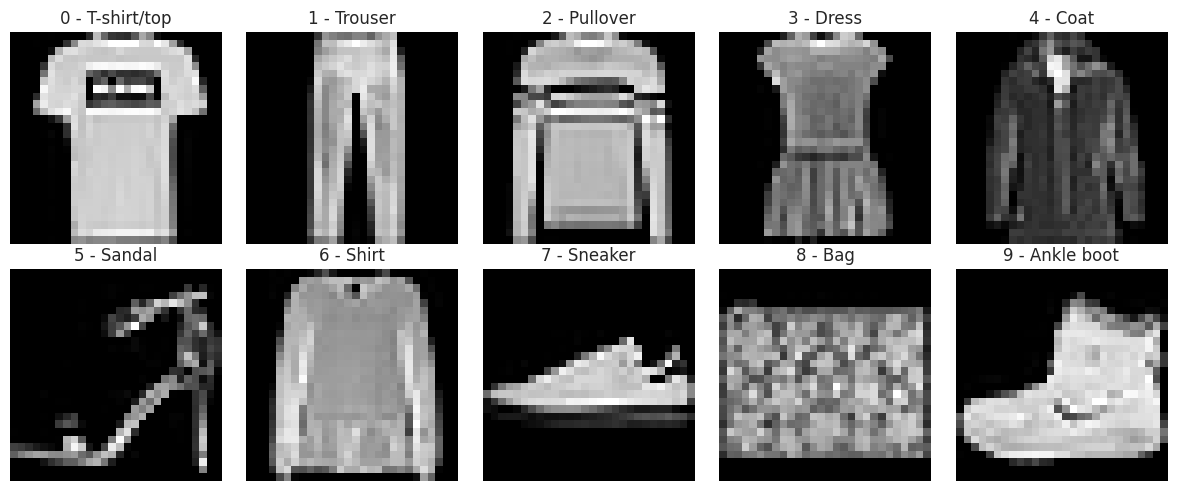

In [9]:
train_raw = FashionMNIST(root='./data', train=True, download=True)
test_raw = FashionMNIST(root='./data', train=False, download=True)

print(f'Tipo do dataset: {type(train_raw)}')
print(f'Tamanho treino: {len(train_raw)} | Tamanho teste: {len(test_raw)}\n')

label_names = train_raw.classes
print(label_names)
print(f'Mapeamento classe->id: {train_raw.class_to_idx}\n')

x0 = train_raw.data[0].unsqueeze(0).float() / 255.0
y0 = int(train_raw.targets[0].item())
C, H, W = x0.shape
print(f'Shape de uma amostra x: {tuple(x0.shape)} -> C={C}, H={H}, W={W}')
print(f'Dtype de x: {x0.dtype}')
print(f'Faixa de x: [{x0.min().item():.3f}, {x0.max().item():.3f}]\n')
print('Fica claro que os dados, de fato, estao normalizados para [0,1] nessa etapa')

train_counts = pd.Series(train_raw.targets.numpy()).value_counts().sort_index()
test_counts = pd.Series(test_raw.targets.numpy()).value_counts().sort_index()
dist_df = pd.DataFrame({
    'target_id': range(len(label_names)),
    'target_str': label_names,
    'train_count': train_counts.values,
    'test_count': test_counts.values,
})
dist_df['train_pct'] = (dist_df['train_count'] / len(train_raw) * 100).round(2)
dist_df['test_pct'] = (dist_df['test_count'] / len(test_raw) * 100).round(2)

display(dist_df)
print(f"Soma treino: {dist_df['train_count'].sum()} | Soma teste: {dist_df['test_count'].sum()}")

X_flat = train_raw.data.view(len(train_raw), -1).numpy().astype(np.float32) / 255.0
pixel_cols = [f'px_{i}' for i in range(784)]
df_tab = pd.DataFrame(X_flat, columns=pixel_cols)
df_tab['target_id'] = train_raw.targets.numpy()

print(f'Shape: {df_tab.shape} - (784 pixels + target_id)')
display(pd.concat([df_tab.dtypes.head(2), df_tab.dtypes.tail(2)]))

display(df_tab.head(3))

df_vis = df_tab.copy()
df_vis['target_str'] = df_vis['target_id'].map(lambda i: label_names[i])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls in range(len(label_names)):
    idx = np.where(train_raw.targets.numpy() == cls)[0][0]
    img = (train_raw.data[idx].float() / 255.0).numpy()
    lbl = int(train_raw.targets[idx].item())
    axes[cls // 5, cls % 5].imshow(img, cmap='gray')
    axes[cls // 5, cls % 5].set_title(f'{lbl} - {label_names[lbl]}')
    axes[cls // 5, cls % 5].axis('off')
plt.tight_layout()
plt.show()

Na exploração inicial, a estrutura da base foi confirmada por etapas: tipo do objeto, tamanho de treino/teste, mapeamento das classes e formato real da entrada. Com a conversão para float e divisão por 255, cada imagem fica como `(C,H,W) = (1,28,28)`, com pixel em `[0,1]`, e target numérico de 0 a 9.

Também foi montada uma visão tabular para inspeção dos dados: 784 colunas de pixel e 1 coluna de target (`target_id`), totalizando 785 colunas. O nome da classe (`target_str`) foi mantido apenas como apoio de visualização, sem entrar no dataset principal.

Outro ponto importante é o tamanho da base. Em comparação com a Questão 1 (MLP, base tabular médica menor), aqui há 60.000 amostras de treino e 10.000 de teste. Além disso, a distribuição por classe veio equilibrada, sem sinal de desbalanceamento nessa etapa inicial.

### 2.2 Preparação dos Dados

In [10]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

X_all = train_raw.data.unsqueeze(1).float() / 255.0
y_all = train_raw.targets.long()

X_all = (X_all - 0.5) / 0.5
X_test = test_raw.data.unsqueeze(1).float() / 255.0
X_test = (X_test - 0.5) / 0.5
y_test_fashion = test_raw.targets.long()

train_idx, val_idx = train_test_split(
    np.arange(len(X_all)),
    test_size=0.15,
    random_state=seed,
    stratify=y_all.numpy()
)

full_train = TensorDataset(X_all, y_all)
train_dataset = torch.utils.data.Subset(full_train, train_idx)
val_dataset = torch.utils.data.Subset(full_train, val_idx)
test_dataset = TensorDataset(X_test, y_test_fashion)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample_x, sample_y = next(iter(train_loader))
print(f'Shape batch treino: {tuple(sample_x.shape)}')
print(f'Shape labels batch treino: {tuple(sample_y.shape)}')
print(f'Tamanho treino: {len(train_dataset)} | validacao: {len(val_dataset)} | teste: {len(test_dataset)}')
print('Preparacao concluida.')

Shape batch treino: (128, 1, 28, 28)
Shape labels batch treino: (128,)
Tamanho treino: 51000 | validacao: 9000 | teste: 10000
Preparacao concluida.


### 2.3 Configuração + Treinamento + Validação

Nesta etapa ficam juntas a definição das configurações, a arquitetura da CNN e o loop de treino/validação. A proposta é comparar duas configurações sob o mesmo protocolo (mesma divisão e mesmos hiperparâmetros-base), acompanhar as curvas por época e selecionar o melhor estado pelo menor valor de loss na validação.

A escolha por uma arquitetura CNN em vez de uma MLP para este problema é justificada pela natureza espacial e estrutural das imagens do dataset em questão. Enquanto a MLP exige o achatamento de uma imagem em um vetor unidimensional, o que é problemático para a relação de vizinhança entre os pixels e causa uma explosão no número de parâmetros, a CNN preserva a matriz bidimensional do dado. Utilizando conectividade local e compartilhamento de pesos através do kernel, a CNN é capaz de capturar características, como bordas, costuras e etc, de forma eficiente, além de mitigar invariância à mudança na posição do artefato em análise, o que permite o modelo reconhecer a peça mesmo que ela sofra deslocamentos.

In [11]:
num_classes = 10
input_channels = 1

cnn_train_params = {
    'epochs': 8,
    'learning_rate': 1e-3,
    'batch_size': batch_size,
}

cnn_configs = {
    'Config A': {
        'channels': [16, 32],
        'fc_dim': 64,
        'dropout': 0.1,
        'weight_decay': 0.0,
    },
    'Config B': {
        'channels': [32, 64, 128],
        'fc_dim': 128,
        'dropout': 0.3,
        'weight_decay': 1e-4,
    }
}

class CNNModel(nn.Module):
    def __init__(self, channels, fc_dim, dropout=0.0, num_classes=10):
        super().__init__()

        conv_blocks = []
        in_ch = 1
        for out_ch in channels:
            conv_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            conv_blocks.append(nn.ReLU())
            conv_blocks.append(nn.MaxPool2d(2))
            in_ch = out_ch
        self.features = nn.Sequential(*conv_blocks)

        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1] * 4 * 4, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

print('Configuracoes da CNN:')
display(pd.DataFrame(cnn_configs).T)
print('Parametros de treino CNN:')
display(pd.DataFrame([cnn_train_params]))

Configuracoes da CNN:


,channels,fc_dim,dropout,weight_decay
Config A,"[16, 32]",64,0.1,0.0
Config B,"[32, 64, 128]",128,0.3,0.0001


Parametros de treino CNN:


,epochs,learning_rate,batch_size
0,8,0.001,128


,config,best_val_loss
0,Config B,0.228934
1,Config A,0.326659


Melhor configuracao na validacao: Config B


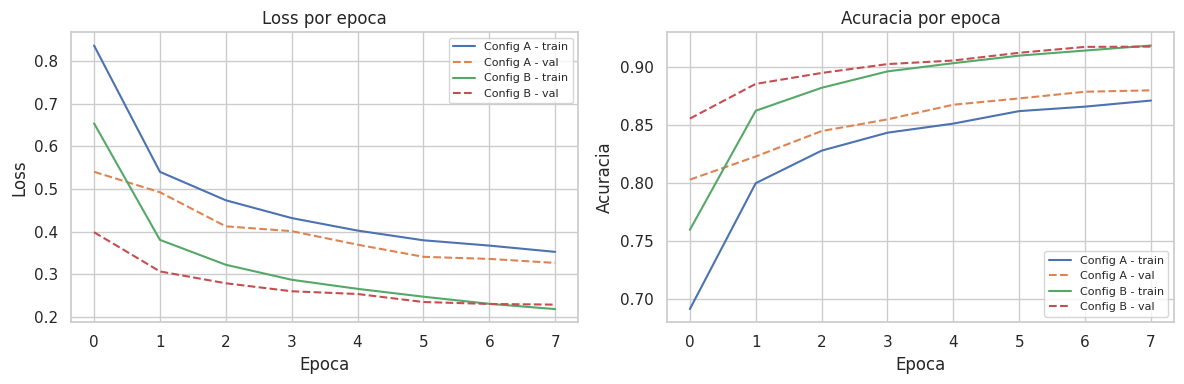

In [12]:
def evaluate_loader(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            preds = torch.argmax(logits, dim=1)
            loss_sum += loss.item() * yb.size(0)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    avg_loss = loss_sum / total
    acc = correct / total
    return avg_loss, acc, torch.cat(all_preds).numpy(), torch.cat(all_targets).numpy()

def train_cnn_model(config):
    model = CNNModel(
        config['channels'],
        fc_dim=config['fc_dim'],
        dropout=config['dropout'],
        num_classes=num_classes
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=cnn_train_params['learning_rate'],
        weight_decay=config['weight_decay']
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None

    for _ in range(cnn_train_params['epochs']):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)
            train_loss_sum += loss.item() * yb.size(0)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total
        val_loss, val_acc, _, _ = evaluate_loader(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history, best_val_loss

cnn_runs = {}
for cfg_name, cfg in cnn_configs.items():
    model, history, best_val = train_cnn_model(cfg)
    cnn_runs[cfg_name] = {
        'model': model,
        'history': history,
        'best_val_loss': best_val,
    }

cnn_val_df = pd.DataFrame([
    {'config': name, 'best_val_loss': run['best_val_loss']}
    for name, run in cnn_runs.items()
]).sort_values('best_val_loss').reset_index(drop=True)

cnn_best_name = cnn_val_df.loc[0, 'config']
cnn_best_model = cnn_runs[cnn_best_name]['model']

display(cnn_val_df)
print(f'Melhor configuracao na validacao: {cnn_best_name}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cfg_name, run in cnn_runs.items():
    axes[0].plot(run['history']['train_loss'], label=f'{cfg_name} - train')
    axes[0].plot(run['history']['val_loss'], linestyle='--', label=f'{cfg_name} - val')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

for cfg_name, run in cnn_runs.items():
    axes[1].plot(run['history']['train_acc'], label=f'{cfg_name} - train')
    axes[1].plot(run['history']['val_acc'], linestyle='--', label=f'{cfg_name} - val')
axes[1].set_title('Acuracia por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Acuracia')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.4 Métricas

A avaliação considera acurácia, matriz de confusão e exemplos qualitativos de acertos/erros do melhor modelo.

Resumo no teste:


,config,test_loss,accuracy
0,Config B,0.2507,0.9087
1,Config A,0.3588,0.8713


Matrizes de confusao:

Config A


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,827,0,23,41,13,1,84,0,11,0
Real 1,1,959,1,29,5,0,4,0,1,0
Real 2,12,0,749,10,167,0,55,0,7,0
Real 3,25,3,9,883,49,0,26,0,5,0
Real 4,1,0,40,26,909,0,21,0,3,0
Real 5,0,0,0,0,0,953,0,35,2,10
Real 6,152,0,65,38,187,0,545,0,13,0
Real 7,0,0,0,0,0,4,0,983,0,13
Real 8,2,1,7,2,6,1,6,5,970,0
Real 9,0,0,0,0,0,2,0,62,1,935



Config B


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6,Pred 7,Pred 8,Pred 9
Real 0,898,0,10,22,2,1,59,0,8,0
Real 1,4,978,1,13,3,0,0,0,1,0
Real 2,17,1,860,13,53,0,53,0,3,0
Real 3,18,2,7,926,22,0,23,0,2,0
Real 4,0,2,51,36,836,0,72,0,3,0
Real 5,0,0,0,0,0,979,0,11,2,8
Real 6,145,2,57,28,63,0,695,0,10,0
Real 7,0,0,0,0,0,8,0,962,1,29
Real 8,3,1,3,4,2,1,1,3,982,0
Real 9,0,0,0,0,0,2,1,26,0,971



Top confusoes do melhor modelo (Config B):


,real_id,pred_id,real,pred,erros
0,6,0,Shirt,T-shirt/top,145
1,4,6,Coat,Shirt,72
2,6,4,Shirt,Coat,63
3,0,6,T-shirt/top,Shirt,59
4,6,2,Shirt,Pullover,57
5,2,4,Pullover,Coat,53
6,2,6,Pullover,Shirt,53
7,4,2,Coat,Pullover,51
8,4,3,Coat,Dress,36
9,7,9,Sneaker,Ankle boot,29


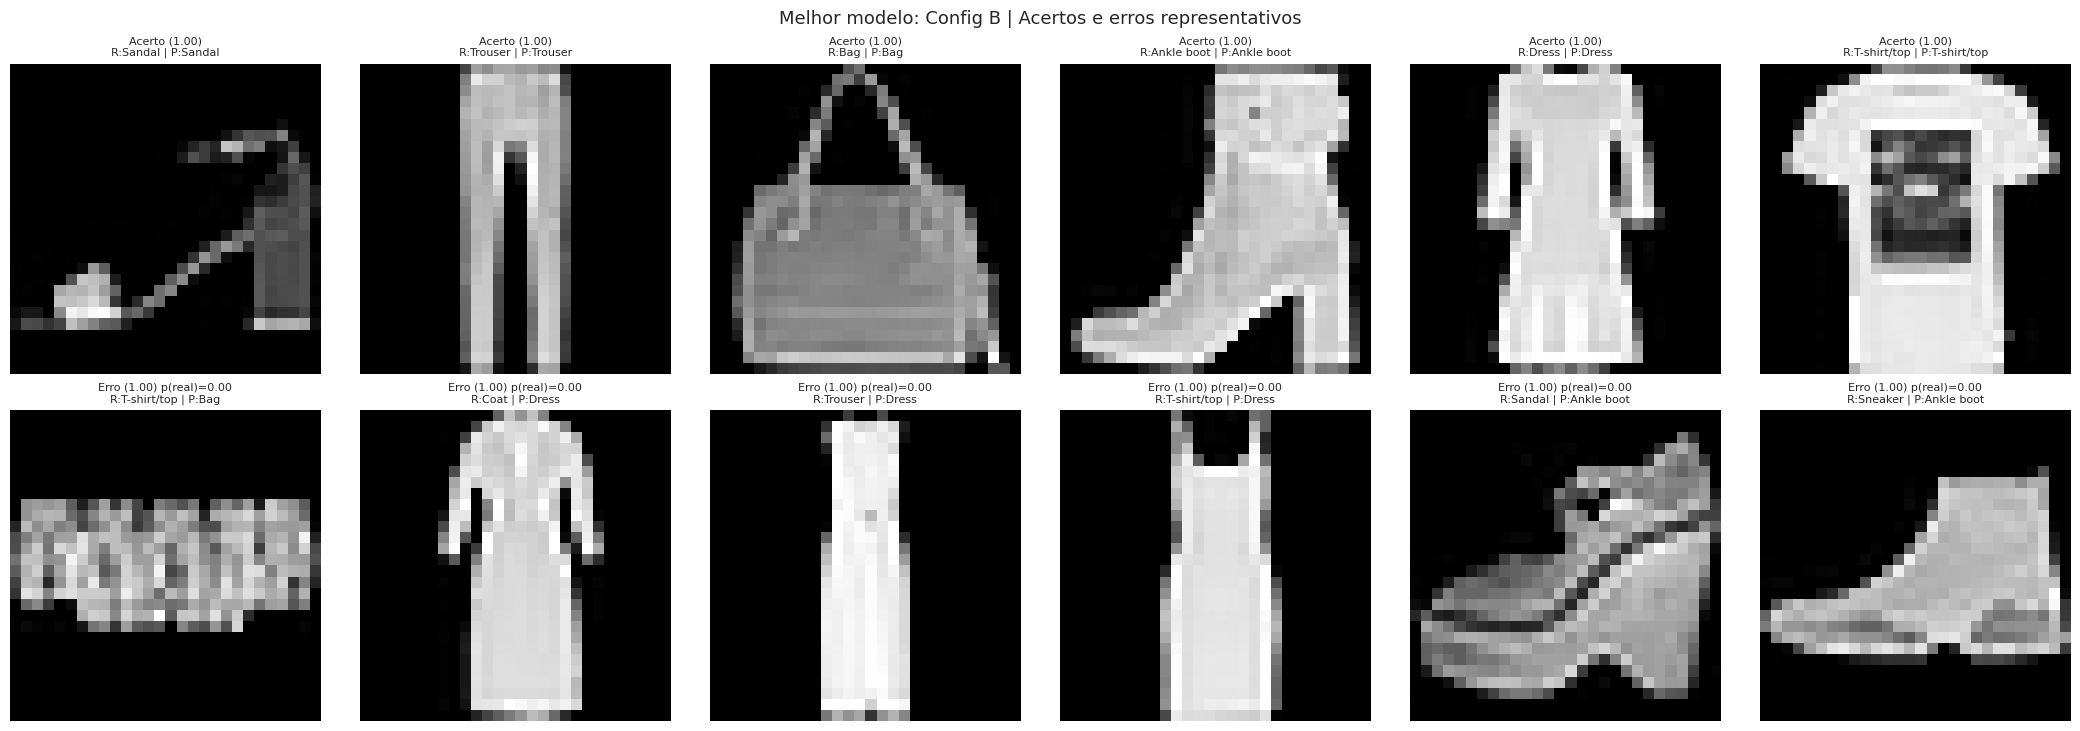

In [13]:
cnn_results = []
cnn_conf_mats = {}

for cfg_name, run in cnn_runs.items():
    model = run['model']
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_pred, y_true = evaluate_loader(model, test_loader, criterion)
    cm = confusion_matrix(y_true, y_pred)

    cnn_results.append({
        'config': cfg_name,
        'test_loss': test_loss,
        'accuracy': test_acc,
    })
    cnn_conf_mats[cfg_name] = cm

cnn_results_df = pd.DataFrame(cnn_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
cnn_results_fmt = cnn_results_df.copy()
for c in ['test_loss', 'accuracy']:
    cnn_results_fmt[c] = cnn_results_fmt[c].map(lambda x: f'{x:.4f}')

print('Resumo no teste:')
display(cnn_results_fmt)

print('Matrizes de confusao:')
for cfg_name, cm in cnn_conf_mats.items():
    print(f'\n{cfg_name}')
    display(pd.DataFrame(cm, index=[f'Real {i}' for i in range(10)], columns=[f'Pred {i}' for i in range(10)]))

best_cfg = cnn_best_name
best_cm = cnn_conf_mats[best_cfg]

off_diag = []
for real_id in range(best_cm.shape[0]):
    for pred_id in range(best_cm.shape[1]):
        if real_id != pred_id and best_cm[real_id, pred_id] > 0:
            off_diag.append({
                'real_id': real_id,
                'pred_id': pred_id,
                'real': label_names[real_id],
                'pred': label_names[pred_id],
                'erros': int(best_cm[real_id, pred_id]),
            })

top_confusions_df = pd.DataFrame(off_diag).sort_values('erros', ascending=False).head(10).reset_index(drop=True)
print(f'\nTop confusoes do melhor modelo ({best_cfg}):')
display(top_confusions_df)

best_model = cnn_runs[best_cfg]['model']
best_model.eval()

x_test_all, y_test_all = [], []
for xb, yb in test_loader:
    x_test_all.append(xb)
    y_test_all.append(yb)
x_test_all = torch.cat(x_test_all)
y_test_all = torch.cat(y_test_all)

with torch.no_grad():
    logits = best_model(x_test_all.to(device)).cpu()
    probs = torch.softmax(logits, dim=1)
    pred_all = torch.argmax(probs, dim=1)
    conf_all = probs.max(dim=1).values

correct_idx = (pred_all == y_test_all).nonzero(as_tuple=True)[0]
wrong_idx = (pred_all != y_test_all).nonzero(as_tuple=True)[0]

n_show = 6

def pick_diverse_correct(indices, true_labels, scores, max_items):
    selected = []
    used_classes = set()
    ranked = indices[torch.argsort(scores[indices], descending=True)]

    for idx in ranked.tolist():
        cls = int(true_labels[idx].item())
        if cls not in used_classes:
            selected.append(idx)
            used_classes.add(cls)
        if len(selected) == max_items:
            break

    if len(selected) < max_items:
        for idx in ranked.tolist():
            if idx not in selected:
                selected.append(idx)
            if len(selected) == max_items:
                break

    return np.array(selected, dtype=int)

def pick_diverse_wrong(indices, true_labels, pred_labels, scores, max_items):
    selected = []
    used_pairs = set()
    ranked = indices[torch.argsort(scores[indices], descending=True)]

    for idx in ranked.tolist():
        pair = (int(true_labels[idx].item()), int(pred_labels[idx].item()))
        if pair not in used_pairs:
            selected.append(idx)
            used_pairs.add(pair)
        if len(selected) == max_items:
            break

    if len(selected) < max_items:
        for idx in ranked.tolist():
            if idx not in selected:
                selected.append(idx)
            if len(selected) == max_items:
                break

    return np.array(selected, dtype=int)

sel_correct = pick_diverse_correct(correct_idx, y_test_all, conf_all, n_show) if len(correct_idx) > 0 else np.array([], dtype=int)
sel_wrong = pick_diverse_wrong(wrong_idx, y_test_all, pred_all, conf_all, n_show) if len(wrong_idx) > 0 else np.array([], dtype=int)

def denorm_for_plot(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7.2), constrained_layout=True)
fig.suptitle(f'Melhor modelo: {best_cfg} | Acertos e erros representativos', fontsize=13)

for i in range(n_show):
    axes[0, i].axis('off')
    axes[1, i].axis('off')

for i, idx in enumerate(sel_correct):
    img = denorm_for_plot(x_test_all[idx]).squeeze(0)
    t = y_test_all[idx].item()
    p = pred_all[idx].item()
    conf = conf_all[idx].item()
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Acerto ({conf:.2f})\nR:{label_names[t]} | P:{label_names[p]}', fontsize=8)
    axes[0, i].axis('off')

for i, idx in enumerate(sel_wrong):
    img = denorm_for_plot(x_test_all[idx]).squeeze(0)
    t = y_test_all[idx].item()
    p = pred_all[idx].item()
    conf = conf_all[idx].item()
    prob_true = probs[idx, t].item()
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(
        f'Erro ({conf:.2f}) p(real)={prob_true:.2f}\nR:{label_names[t]} | P:{label_names[p]}',
        fontsize=8
    )
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Acertos', fontsize=11)
axes[1, 0].set_ylabel('Erros', fontsize=11)
plt.show()

### 2.5 Análise

A comparação entre as configurações foi realizada de forma consistente, submetendo ambos os modelos ao mesmo protocolo de treinamento e seleção de hiperparâmetros. A Configuração B apresentou um desempenho superior à Configuração A, tanto na estabilidade das curvas de convergência quanto nas métricas finais de teste, demonstrando que o aumento na profundidade da rede e a maior capacidade de extração de características foram traduzidos em um ganho real de performance.

Ao analisarmos as curvas de perda ao longo das épocas, notamos que ambos os modelos aprendem de maneira estável, o que indica ausência de problemas significativos de underfitting. Também não observamos sinais de overfitting acentuado, já que a perda de validação acompanha a tendência de queda do treino sem sofrer divergências. A diferença entre os valores de treino e validação, ainda que presente, é um reflexo esperado do uso de regularização via Dropout e Weight Decay, que funcionam como mecanismos de controle para evitar a memorização do ruído dos dados.

A matriz de confusão e os erros observados no teste deixam claro que as falhas do modelo ocorrem majoritariamente entre categorias com shapes semelhantes. É comum que peças como T-shirts, Shirts, Pullovers e Coats sejam confundidas entre si, dado que o dataset Fashion-MNIST possui resolução limitada de 28x28 pixels. Em imagens com baixo detalhamento e sem cor, a distinção entre texturas de tecidos ou cortes específicos dessas peças é um desafio, mesmo para modelos mais profundos. 

Por fim, a escolha pela CNN justifica-se pela sua capacidade de explorar a estrutura espacial das imagens. Ao contrário da abordagem tabular, as camadas convolucionais permitem que o modelo aprenda a reconhecer padrões hierárquicos, como contornos e formas, de forma eficiente e com menos parâmetros, lidando com dependência e relação espacial. O uso de pooling contribui para que o modelo mantenha a precisão mesmo diante de pequenas variações na posição ou no enquadramento das peças. 

---
## Questão 3: GAN - MNIST


### 3.1 Descrição e entendimento do problema

Nem sempre o objetivo de redes neurais é predição, em muitos casos queremos gerar novos dados que se pareçam com dados reais já existentes e possam ser usados em tarefas futuras de classificação, análise ou enriquecimento de datasets. Nesse cenário, GANs são um instrumento poderoso, pois permitem aprender a distribuição dos dados reais e gerar novas amostras sinteticamente que mantêm características semelhantes (a partir de certo ponto no treinamento).

Uma GAN funciona a partir de redes adversárias, sendo elas o Gerador, que cria imagens falsas a partir de vetores do vetor latente, e o Discriminador, que tenta distinguir imagens reais (do dataset) das imagens geradas. Nesse processo competitivo, ambas melhoram iterativamente até que o Gerador consegue produzir amostras capazes de enganar o Discriminador.

Comparando duas configurações de GAN, uma mais simples e outra com maior capacidade, poderemos observar como a arquitetura influencia a qualidade das amostras geradas.

O [dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset) em questão é um bom ponto de partida pois é uma base clássica de redes neurais, com imagens simples e 10 dígitos manuscritos. Percebemos que as imagens tem uma geometria e formas simplificadas, o que permite uma análise e evolução do processo de treinamento das redes, especialmente a rede Geradora, que tem a tarefa de aprender a criar dígitos que se pareçam com os reais.

### 3.2 Implementação e Configuração


In [14]:
mnist_raw = MNIST(root='./data', train=True, download=True)

X_mnist = mnist_raw.data.unsqueeze(1).float() / 255.0
X_mnist = (X_mnist - 0.5) / 0.5
y_mnist = mnist_raw.targets.long() 

batch_size_gan = 128
gan_dataset = TensorDataset(X_mnist, y_mnist)
gan_loader = DataLoader(gan_dataset, batch_size=batch_size_gan, shuffle=True)

class DiscriminatorA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x): 
        return self.net(x)

class GeneratorA(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1, 28, 28)

class DiscriminatorB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x): 
        return self.net(x)

class GeneratorB(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1, 28, 28)

gan_configs = {
    'Config A': {
        'z_dim': 64,
        'lr': 0.0002,
        'beta1': 0.9, 
        'epochs': 30,
        'D_class': DiscriminatorA,
        'G_class': GeneratorA
    },
    'Config B': {
        'z_dim': 100,
        'lr': 0.0002,
        'beta1': 0.2,
        'epochs': 30,
        'D_class': DiscriminatorB,
        'G_class': GeneratorB
    }
}
print(f"Base carregada. Formato X: {X_mnist.shape}, Formato y: {y_mnist.shape}")
print("Configurações das arquiteturas A e B definidas.")

Base carregada. Formato X: torch.Size([60000, 1, 28, 28]), Formato y: torch.Size([60000])
Configurações das arquiteturas A e B definidas.


### 3.3 Treino e Amostras Obtidas

Treinando Config A...
Treinando Config B...


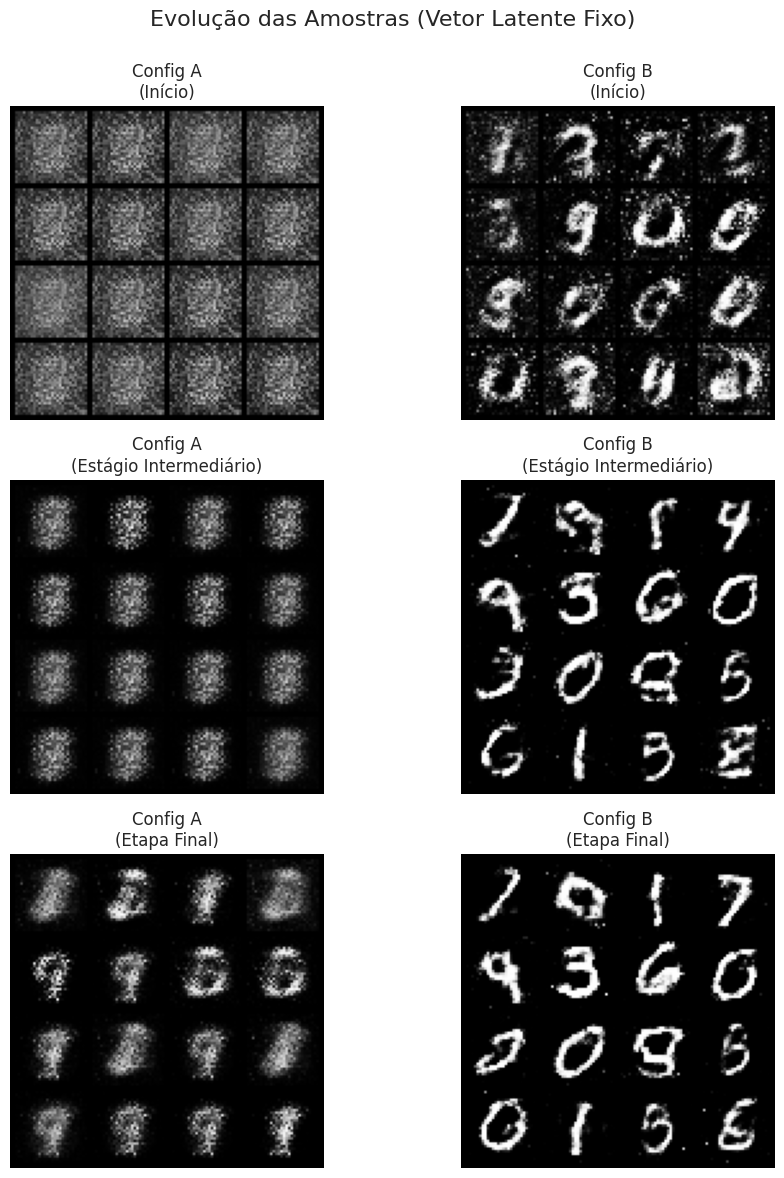

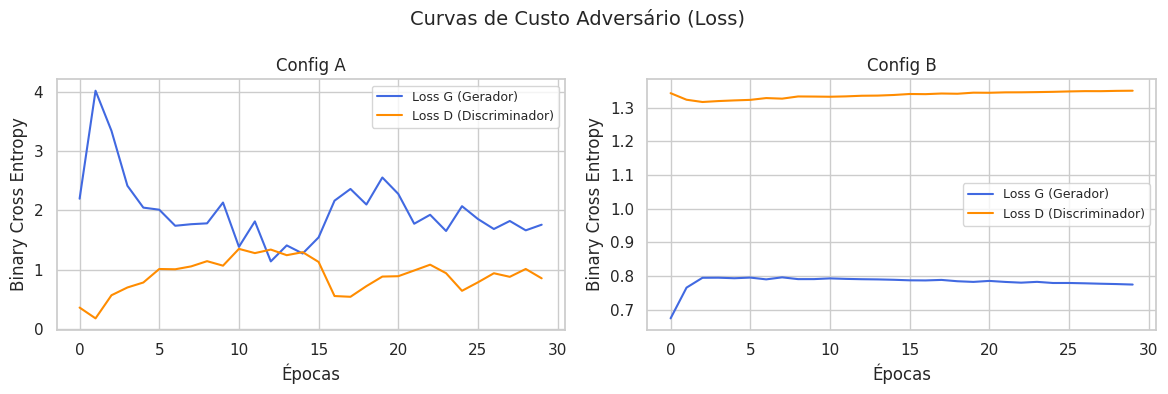

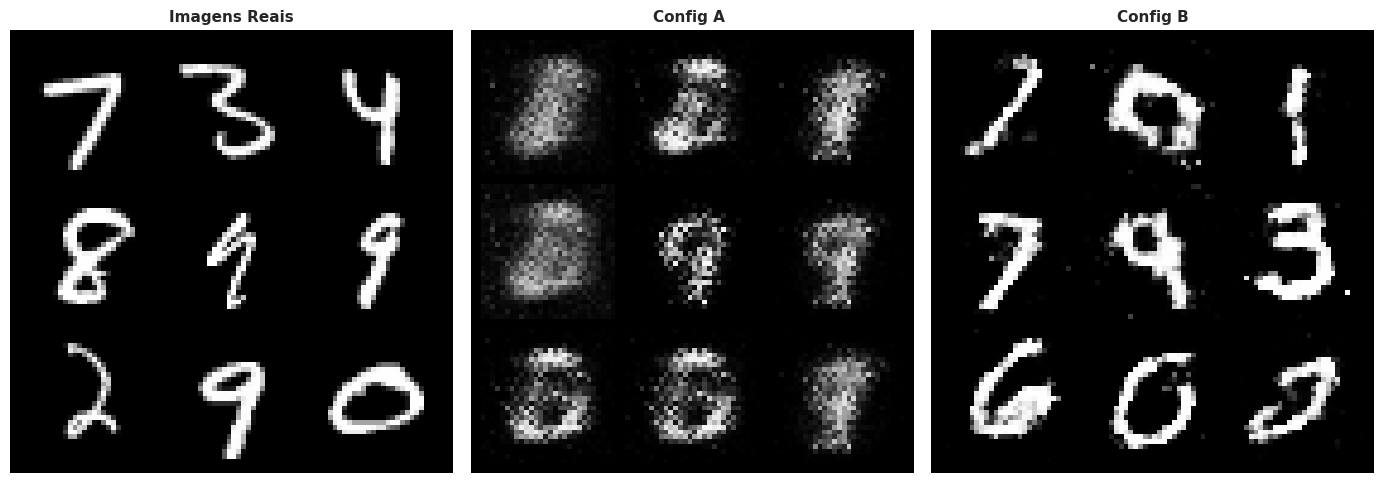

In [15]:
criterion_gan = nn.BCELoss()

def train_gan_model(nome_config, config, loader):
    print(f"Treinando {nome_config}...")
    
    D = config['D_class']().to(device)
    G = config['G_class'](config['z_dim']).to(device)
    
    opt_D = optim.Adam(D.parameters(), lr=config['lr'], betas=(config['beta1'], 0.999))
    opt_G = optim.Adam(G.parameters(), lr=config['lr'], betas=(config['beta1'], 0.999))
    
    epochs = config['epochs']
    z_dim = config['z_dim']
    
    fixed_z = torch.randn(16, z_dim).to(device)
    
    hist = {'d_loss': [], 'g_loss': []}
    amostras_checkpoints = {}
    
    pontos_extracao = [0, epochs // 2, epochs - 1]
    
    for ep in range(epochs):
        D.train()
        G.train()
        
        d_loss_ep = 0.0
        g_loss_ep = 0.0
        
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)
            
            label_real = torch.ones(bs, 1).to(device)
            label_fake = torch.zeros(bs, 1).to(device)
            
            opt_D.zero_grad()
            
            out_real = D(real_imgs)
            loss_d_real = criterion_gan(out_real, label_real)
            
            z = torch.randn(bs, z_dim).to(device)
            fake_imgs = G(z)
            out_fake = D(fake_imgs.detach())
            loss_d_fake = criterion_gan(out_fake, label_fake)
            
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_D.step()
            
            opt_G.zero_grad()
            
            out_fake_for_g = D(fake_imgs)
            loss_g = criterion_gan(out_fake_for_g, label_real)
            
            loss_g.backward()
            opt_G.step()
            
            d_loss_ep += loss_d.item()
            g_loss_ep += loss_g.item()
            
        hist['d_loss'].append(d_loss_ep / len(loader))
        hist['g_loss'].append(g_loss_ep / len(loader))
        
        if ep in pontos_extracao:
            G.eval()
            with torch.no_grad():
                imgs_gen = ((G(fixed_z).cpu() * 0.5) + 0.5).clamp(0, 1)
                
                if ep == 0:
                    estagio = 'Início'
                elif ep == epochs // 2:
                    estagio = 'Estágio Intermediário'
                else:
                    estagio = 'Etapa Final'
                    
                amostras_checkpoints[estagio] = imgs_gen
                
    return hist, amostras_checkpoints

gan_resultados = {}
for nome, cfg in gan_configs.items():
    hist, amostras = train_gan_model(nome, cfg, gan_loader)
    gan_resultados[nome] = {'hist': hist, 'amostras': amostras}

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("Evolução das Amostras (Vetor Latente Fixo)", fontsize=16)

estagios = list(list(gan_resultados.values())[0]['amostras'].keys())

for idx_estagio, estagio in enumerate(estagios):
    for idx_config, (nome_cfg, res) in enumerate(gan_resultados.items()):
        
        imgs = res['amostras'][estagio]
        grid = make_grid(imgs, nrow=4, padding=2).numpy()
        grid = np.transpose(grid, (1, 2, 0))
        
        axes[idx_estagio, idx_config].imshow(grid, cmap='gray')
        axes[idx_estagio, idx_config].set_title(f"{nome_cfg}\n({estagio})")
        axes[idx_estagio, idx_config].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de Custo Adversário (Loss)", fontsize=14)

for idx_cfg, (nome_cfg, res) in enumerate(gan_resultados.items()):
    ax = axes[idx_cfg]
    ax.plot(res['hist']['g_loss'], label='Loss G (Gerador)', color='royalblue')
    ax.plot(res['hist']['d_loss'], label='Loss D (Discriminador)', color='darkorange')
    ax.set_title(nome_cfg)
    ax.set_xlabel("Épocas")
    ax.set_ylabel("Binary Cross Entropy")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

real_batch, _ = next(iter(gan_loader))
real_batch_viz = ((real_batch.cpu() * 0.5) + 0.5).clamp(0, 1)[:9]  

fig, axes = plt.subplots(1, 3, figsize=(14, 8))

grid_real = make_grid(real_batch_viz, nrow=3, padding=2).numpy()
grid_real = np.transpose(grid_real, (1, 2, 0)).squeeze()
axes[0].imshow(grid_real, cmap='gray')
axes[0].set_title("Imagens Reais", fontsize=11, fontweight='bold')
axes[0].axis('off')

imgs_a_final = gan_resultados['Config A']['amostras']['Etapa Final'][:9]
grid_a = make_grid(imgs_a_final, nrow=3, padding=2).numpy()
grid_a = np.transpose(grid_a, (1, 2, 0)).squeeze()
axes[1].imshow(grid_a, cmap='gray')
axes[1].set_title("Config A ", fontsize=11, fontweight='bold')
axes[1].axis('off')

imgs_b_final = gan_resultados['Config B']['amostras']['Etapa Final'][:9]
grid_b = make_grid(imgs_b_final, nrow=3, padding=2).numpy()
grid_b = np.transpose(grid_b, (1, 2, 0)).squeeze()
axes[2].imshow(grid_b, cmap='gray')
axes[2].set_title("Config B", fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.4 Análise

A diferença entre as duas configurações é nítida, embora ambas ainda fiquem longe da perfeição do dataset real. A Configuração A entregou amostras ruidosas e sem estrutura definida. Usar dados ruins assim para aumento de dados é perigoso, pois cai no clássico garbage in, garbage out, inserindo lixo na base e prejudicando o desempenho de um classificador posterior. A Configuração B foi muito melhor e gerou dígitos legíveis na etapa final, mas ainda exibe falhas consideráveis.

Esse comportamento se reflete direto nas curvas de perda. Na Configuração A, a loss do Gerador sofre oscilações com picos, gerando saltos bruscos e desconexos a cada estágio visual a partir do ruído inicial. Na Configuração B, a loss do gerador cai e satura rápido. Essa estabilização precoce explica por que as imagens mudam pouco entre o estágio intermediário e a etapa final. Isso mostra que o aprendizado estagnou e que simplesmente aumentar o número de épocas não adiantaria. Assim, o caminho para corrigir esses números deformados seria de fato aprofundar a rede.

As escolhas de design justificam esses resultados. A Configuração A usou ReLU simples com beta1=0.9, tornando o otimizador muito inercial e travado. A Configuração B combinou LeakyReLU(0.2), que deixa os gradientes passarem mesmo no lado negativo e evita que a rede morra, BatchNorm para estabilizar as ativações internas do gerador, e um beta1 menor (0.2) para dar mais agilidade ao algoritmo contra as mudanças do adversário. O dropout no discriminador também foi vital para que ele não memorizasse o dataset real e esmagasse o gerador antes da hora.

Fica evidente que as GANs são ferramentas poderosas para modelagem generativa e síntese de dados, mas o sucesso depende de combinar a capacidade e a profundidade do modelo com a complexidade do padrão que se tenta replicar (dataset real observado).

---
## Questão 4: GNN - Cora

### 4.1 Descrição e entendimento do problema

O [dataset](https://relational.fit.cvut.cz/dataset/CORA) é uma rede de citações de artigos científicos. Diferente dos problemas anteriores, onde os dados eram isolados em linhas de uma tabela (Questão 1) ou em pixels independentes (Questões 2 e 3), este é um problema relacional e estruturado em rede.

* **Nós:** Artigos científicos.
* **Arestas:** Relações direcionadas de citação entre os artigos.
* **Target:** Classificar cada artigo em uma de 7 classes (áreas da computação, como *Machine Learning*, *Theory*, etc.).

A natureza do problema é relacional porque a categoria de um artigo está fortemente correlacionada à categoria dos artigos que ele cita ou pelos quais é citado. Portanto, não só o conteúdo individual de cada nó é importante, mas também a estrutura de conexões entre os nós.

- **$X$:** Representa a matriz de atributos dos nós. No dataset, cada artigo possui um vetor binário que indica a presença ou ausência de palavras-chave específicas de um vocabulário fixo. Esses atributos capturam a informação textual e isolada de cada publicação.
- **$A$:** Define a topologia do grafo. O PyTorch Geometric gerencia essa estrutura por meio do `edge_index`, uma lista que armazena apenas os pares de índices correspondentes às conexões reais (nó de origem e nó de destino). Essa abordagem baseada em listas de adjacência otimiza significativamente o uso de memória, evitando o armazenamento de uma matriz de adjacência densa $N \times N$, que seria majoritariamente esparsa e ineficiente para redes de grande escala.
- **Embeddings de nós:** São as representações vetoriais geradas pelas camadas da GNN. Ao longo do treinamento, o modelo mapeia nós combinando os seus atributos intrínsecos ($X$) com as informações agregadas de sua vizinhança estrutural ($A$), refinando os vetores para refletirem tanto o conteúdo local quanto o contexto relacional na rede.

Diferente de uma MLP ou de uma CNN, que processam amostras de forma isolada ou em batches independentes, a estrutura de um grafo impede a fragmentação arbitrária das conexões sem perda de contexto relacional. Por esse motivo, o grafo é alimentado integralmente na rede para permitir a difusão plena da informação entre as camadas. Como todo o grafo é processado em bloco conjunto, a segregação entre os conjuntos de treino, validação e teste é feita por meio de máscaras. Essas máscaras delimitam quais nós terão suas funções de perda computadas para a atualização dos gradientes e quais serão isolados apenas para a validação do desempenho métrico final.

In [9]:
dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0]

print(f"Número de artigos (Nós): {data.num_nodes}")
print(f"Número de citações (Arestas): {data.num_edges}")
print(f"Número de atributos por artigo (Features): {dataset.num_node_features}")
print(f"Áreas possíveis (Classes): {dataset.num_classes}\n")

print(f"A base é direcionada? {data.is_directed()}")
print(f"Tem nós isolados? {data.has_isolated_nodes()}")

Número de artigos (Nós): 2708
Número de citações (Arestas): 10556
Número de atributos por artigo (Features): 1433
Áreas possíveis (Classes): 7

A base é direcionada? False
Tem nós isolados? False


### 4.2 Configuração e Treinamento

Com o objetivo de avaliar o impacto prático da profundidade da rede na qualidade das representações, estruturamos duas variações do modelo:

- **Configuração A:** Uma GCN padrão composta por 2 camadas de convolução de grafos (`GCNConv`).
- **Configuração B:** Uma GCN estendida contendo 4 camadas `GCNConv`.

O treinamento será realizado utilizando a função de perda *Cross Entropy Loss* e o otimizador *Adam*. Para isolar o efeito da profundidade e garantir uma comparação justa, fixamos a dimensão dos embeddings intermediários em **16** e aplicamos a função de ativação **ReLU** entre as camadas em ambas as configurações.

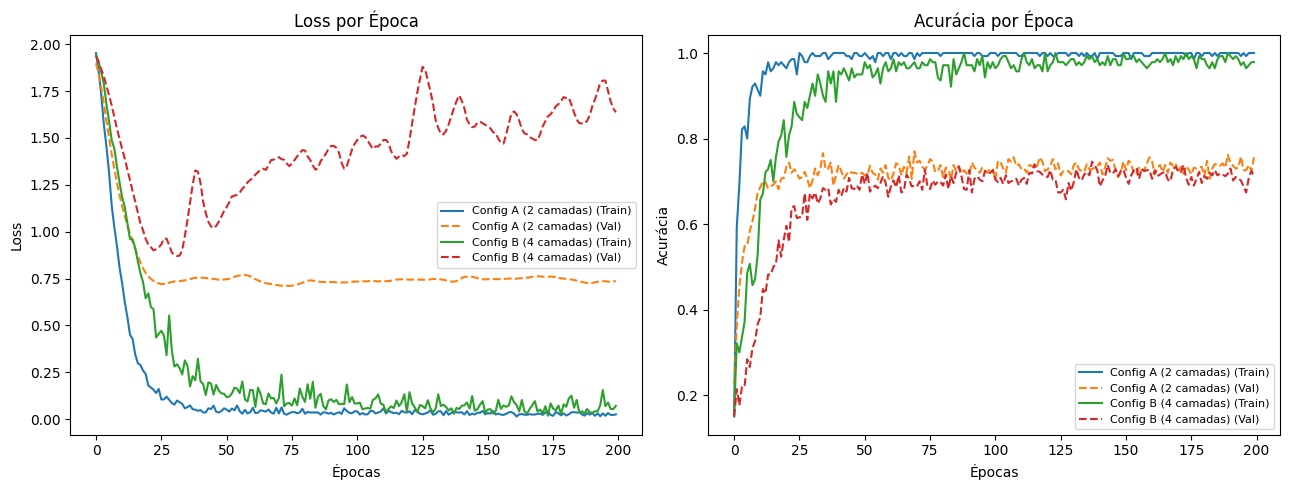

In [23]:
class GCNModel(nn.Module):
    def __init__(self, in_features, hidden_dim, out_classes, num_layers, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.dropout = dropout
        
        self.convs.append(GCNConv(in_features, hidden_dim))
        
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            
        self.convs.append(GCNConv(hidden_dim, out_classes))

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
        x = self.convs[-1](x, edge_index)
        return x

cora_configs = {
    'Config A (2 camadas)': {'num_layers': 2, 'hidden_dim': 16, 'epochs': 200, 'lr': 0.01, 'weight_decay': 5e-4},
    'Config B (4 camadas)': {'num_layers': 4, 'hidden_dim': 16, 'epochs': 200, 'lr': 0.01, 'weight_decay': 5e-4}
}

criterion_gcn = nn.CrossEntropyLoss()

def train_gcn_model(config, data):
    model = GCNModel(
        in_features=dataset.num_node_features,
        hidden_dim=config['hidden_dim'],
        out_classes=dataset.num_classes,
        num_layers=config['num_layers']
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    
    for _ in range(config['epochs']):
        model.train()
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index)
        
        loss_train = criterion_gcn(out[data.train_mask], data.y[data.train_mask])
        loss_train.backward()
        optimizer.step()
        
        preds = out.argmax(dim=1)
        acc_train = (preds[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
        
        model.eval()
        with torch.no_grad():
            out_val = model(data.x, data.edge_index)
            loss_val = criterion_gcn(out_val[data.val_mask], data.y[data.val_mask])
            acc_val = (preds[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
            
        hist['train_loss'].append(loss_train.item())
        hist['val_loss'].append(loss_val.item())
        hist['train_acc'].append(acc_train)
        hist['val_acc'].append(acc_val)
        
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            
    model.load_state_dict(best_state)
    return model, hist, best_val_loss

gcn_runs = {}
for name, cfg in cora_configs.items():
    model, hist, best_val = train_gcn_model(cfg, data)
    gcn_runs[name] = {'model': model, 'hist': hist, 'best_val': best_val}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cfg_name, res in gcn_runs.items():
    axes[0].plot(res['hist']['train_loss'], label=f"{cfg_name} (Train)")
    axes[0].plot(res['hist']['val_loss'], linestyle='--', label=f"{cfg_name} (Val)")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

for cfg_name, res in gcn_runs.items():
    axes[1].plot(res['hist']['train_acc'], label=f"{cfg_name} (Train)")
    axes[1].plot(res['hist']['val_acc'], linestyle='--', label=f"{cfg_name} (Val)")
axes[1].set_title("Acurácia por Época")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Acurácia")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Métricas

In [22]:
gcn_results = []
conf_mats_gcn = {}

for name, res in gcn_runs.items():
    model = res['model']
    model.eval()
    
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1)
        
        test_mask = data.test_mask
        acc = (preds[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()
        
        y_true = data.y[test_mask].cpu().numpy()
        y_pred = preds[test_mask].cpu().numpy()
        
        conf_mat = confusion_matrix(y_true, y_pred)
        
        gcn_results.append({'Config': name, 'Acurácia Teste': f"{acc:.4f}"})
        conf_mats_gcn[name] = conf_mat

display(pd.DataFrame(gcn_results).style.hide(axis='index'))

print("\nMatriz de Confusão (Config A):")
display(pd.DataFrame(conf_mats_gcn['Config A (2 camadas)'], 
                     index=[f'Real {i}' for i in range(dataset.num_classes)], 
                     columns=[f'Pred {i}' for i in range(dataset.num_classes)]))

print("\nMatriz de Confusão (Config B):")
display(pd.DataFrame(conf_mats_gcn['Config B (4 camadas)'], 
                     index=[f'Real {i}' for i in range(dataset.num_classes)], 
                     columns=[f'Pred {i}' for i in range(dataset.num_classes)]))

Config,Acurácia Teste
Config A (2 camadas),0.8110
Config B (4 camadas),0.7710



Matriz de Confusão (Config A):


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6
Real 0,94,4,3,9,6,4,10
Real 1,5,79,3,4,0,0,0
Real 2,3,5,132,3,1,0,0
Real 3,18,5,14,243,26,10,3
Real 4,8,1,2,7,126,4,1
Real 5,7,3,4,0,0,80,9
Real 6,4,0,0,1,0,2,57



Matriz de Confusão (Config B):


,Pred 0,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5,Pred 6
Real 0,99,4,3,7,7,4,6
Real 1,3,74,2,11,0,0,1
Real 2,2,2,124,3,5,0,8
Real 3,11,11,9,211,61,12,4
Real 4,6,1,0,4,134,3,1
Real 5,4,3,4,3,0,80,9
Real 6,11,0,0,1,0,3,49


### 4.4 Análise

A estrutura do grafo é importante pois o conteúdo textual isolado de um artigo ganha contexto prático através das relações de citação. Quando as conexões indicam uma área específica, a rede utiliza essa topologia para guiar a classificação e supera a limitação de modelos tradicionais que ignoram as arestas.

Os testes mostram que a Configuração A de duas camadas obteve desempenho superior com 81,10% de acurácia contra 77,10% da Configuração B de quatro camadas. Uma hipótese para explicar essa diferença é o início do fenômeno de over-smoothing, onde mesmo o acréscimo de apenas duas camadas pode fazer com que a replicação de mensagens dilua as características locais e aproxime excessivamente os embeddings dos nós. Essa suposição ganha coerência na matriz de confusão pela queda de acertos da Classe 3, que reduziu de 243 para 211 em favor do aumento de erros direcionados para a Classe 4, uma possível causa disso seria que o modelo mais profundo começou a atenuar as fronteiras de distinção entre essas comunidades de artigos.

Os gráficos de treino e validação mostram um distanciamento claro em ambas as configurações. Enquanto a acurácia de treino sobe até encostar em valores pŕoximos a 100%, a validação trava cedo em um limite bem mais baixo. Esse comportamento indica que o modelo decora os nós de treinamento mas não consegue aplicar esse padrão no resto do grafo, gerando um overfitting visível. Essa instabilidade se agrava na Configuração B, onde a curva de perda na validação começa a subir e a oscilar, confirmando que colocar mais camadas prejudicou as previsões.

---
## Questão 5 - Arquiteturas em Ciência de Dados



## a)

#### MLP
* **Tipo de dado mais adequado:** Dados tabulares estruturados (matrizes de linhas e colunas) onde as variáveis representam as features, as quais geralmente são independentes, sem correlação de proximidade espacial ou dependência temporal direta.
* **Tarefa principal:** Predição supervisionada: classificação de classes e regressão de valores contínuos.
* **Principal força:** Atua como um aproximador de funções para problemas de baixa e média complexidade. Sua implementação é direta e serve como um baseline antes da adoção de modelos especializados.
* **Principal limitação:** A conectividade total entre suas camadas causa aumento significativo no volume de parâmetros quando a dimensão da entrada cresce. Além disso, é sensível à escolha de hiperparâmetros e vulnerável ao *overfitting* ou *underfitting* se o ajuste inicial não for preciso.

#### CNN
* **Tipo de dado mais adequado:** Dados estruturados que apresentam uma relação de vizinhança e dependência espacial entre seus elementos, como imagens, vídeos e espectrogramas.
* **Tarefa principal:** Extração de características e reconhecimento de padrões visuais (bordas, texturas e formas geométricas).
* **Principal força:** Preserva a topologia bidimensional original do dado sem destruir a relação geométrica dos elementos. O uso de filtros convolucionais com compartilhamento de pesos reduz de forma drástica o número de parâmetros necessários em comparação com uma MLP, além de conferir invariância à translação.
* **Principal limitação:** É projetada para topologias de grade regular, sendo assim ineficiente para dados tabulares comuns, além disso não lida nativamente com dependências temporais ou sequenciais de longo prazo, o que historicamente cabe a RNN ou aos Transformers.

#### GAN
* **Tipo de dado mais adequado:** Amostras de alta dimensionalidade (imagens, áudios ou textos) cuja distribuição estatística original se deseja aprender e mapear para a criação de instâncias artificiais inéditas.
* **Tarefa principal:** Modelagem generativa implícita, focada na síntese e geração de novos dados sintéticos a partir de vetores de ruído em um espaço latente.
* **Principal força:** Capacidade única de criar novos registros realistas e plausíveis que simulam o comportamento estatístico da base original. É uma ferramenta estratégica para o enriquecimento de datasets e simulação de cenários.
* **Principal limitação:** Possui uma dinâmica de treinamento complexa e instável baseada em um jogo de soma zero entre o Gerador e o Discriminador. O tempo de processamento é significativamente superior ao de redes preditivas convencionais, exigindo minutos de processamento onde outras redes operam em segundos (nesse experimento), e o modelo é vulnerável a falhas como o *mode collapse*.

#### GNN
* **Tipo de dado mais adequado:** Dados estruturados como grafos, nós e arestas, onde a informação reside tanto nos atributos individuais de cada entidade quanto nas suas conexões e relacionamentos.
* **Tarefa principal:** Aprendizado de representações relacionais e mapeamento de redes, atuando na classificação de nós, predição de conexões e classificação de grafos.
* **Principal força:** Habilidade de fundir atributos locais com a estrutura global do grafo por meio do mecanismo de message passing, lidando com problemas de interdependência.
* **Principal limitação:** Elevado custo computacional para escalar o algoritmo em grafos massivos ou dinâmicos. Além disso, a rede sofre com *oversmoothing* caso camadas demais sejam adicionadas, o que torna as representações dos nós estatisticamente idênticas e destrói o poder preditivo do modelo.

### b)

#### MLP vs. CNN em Dados Visuais
Em dados visuais, a CNN apresenta vantagem sobre a MLP devido à sua capacidade de processar a dependência espacial nativa dos pixels. Pixels geometricamente próximos possuem forte correlação semântica, e os filtros da CNN são desenhados para extrair esses padrões locais de forma hierárquica. 

Por outro lado, a MLP exige o achatamento da matriz da imagem em um vetor unidimensional, desconsiderando a relação de vizinhança física entre os elementos. Além disso, a conectividade da MLP faz com que o número de parâmetros exploda conforme a resolução da imagem cresce. A CNN mitiga isso com o compartilhamento de pesos, tornando o aprendizado eficiente. 

Vale destacar que o domínio visual não se limita a imagens estáticas. No caso de vídeos, além da dependência espacial dos frames (tratada pela CNN), há uma forte dependência temporal entre os frames ao longo do tempo. Para capturar essa dinâmica sequencial CNNs não são suficientes sozinhas.

#### CNN vs. GAN em Problemas com Imagens
A comparação entre CNN e GAN em imagens não estabelece uma relação de superioridade, mas sim de divergência de objetivos. Ambas operam sobre a mesma estrutura de dados (grades de pixels), porém com finalidades opostas.

A CNN é um modelo discriminativo: sua tarefa principal é receber uma imagem de alta dimensionalidade e reduzi-la a um rótulo ou probabilidade de classe (predição e classificação). A GAN é uma arquitetura generativa, ela parte de um vetor de um espaço latente para construir uma imagem inédita e complexa que simule o comportamento estatístico do dataset real. Escolhe-se a CNN para extrair informações e tomar decisões baseadas em imagens, e a GAN para sintetizar novos dados visuais.

#### MLP vs. GNN em Dados Relacionais
Quando lidamos com dados relacionais, onde o valor da informação está na interconexão entre as entidades, a GNN supera a MLP por ser projetada especificamente para topologias não-euclidianas. Um exemplo são as redes de citações acadêmicas, onde o fato de um artigo apontar para outro cria uma relação estrutural explícita que define o contexto do dado.

A MLP falha nesse cenário porque opera sob a premissa de que as linhas de uma tabela são instâncias independentes e isoladas. Ela processa os atributos de um registro, mas é incapaz de enxergar com quem aquele registro se relaciona a rede. A GNN resolve esse gargalo ao utilizar o mecanismo de *message passing*, que funde as características de um nó com a estrutura de sua vizinhança. Assim, para dados estruturados em redes ou grafos, a GNN consegue mapear a topologia das conexões de forma superior à MLP.

### c)

A escolha de uma arquitetura de redes neurais deve começar pela análise da estrutura do dado e do objetivo do problema, dado que cada modelo carrega um viés e motivação específica. Por exemplo, forçar uma rede totalmente conectada (MLP) a processar a dependência espacial de uma grade de pixels (CNN) ou a topologia relacional de um grafo (GNN) quebra a lógica de representação original do dado, gerando um aprendizado ineficiente e altamente propenso ao sobreajuste. Da mesma forma, o objetivo final dita a formulação do sistema, pois mapear um registro para uma classe discreta em uma tarefa de classificação pede uma abordagem discriminativa direta, enquanto estimar a distribuição estatística do dataset subjacente para sintetizar novas instâncias exige o comportamento concorrente de uma arquitetura generativa (GAN).

A necessidade de interpretabilidade e as limitações intrínsecas a cada modelo estabelecem os limites do que é viável e seguro em cada ambiente. Redes excessivamente profundas operam como black-boxes que impedem o rastreamento causal das decisões, o que se torna uma limitação crítica em cenários de alta sensibilidade, como diagnósticos médicos ou análises financeiras reguladas. Nesses contextos, compreender o impacto e o peso relativo de cada variável clínica na decisão final é um requisito tão vital quanto a precisão bruta da resposta, tornando modelos massivos escolhas erradas por sacrificarem a transparência e introduzirem riscos de vieses ocultos em suas camadas latentes, os quais arquiteturas com menor profundidade conseguiriam mitigar ao estabelecerem superfícies de decisão mais inteligíveis e claras, um exemplo disso é que conseguimos classificar células como benignas e malignas na Questão 1 com uma MLP relativamente simples.

O custo computacional determina diretamente a viabilidade da solução. Arquiteturas superdimensionadas demandam infraestruturas de hardware significativamente mais caras, consomem tempo excessivo no processamento e geram uma latência de inferência que pode inviabilizar o atendimento a sistemas em tempo real. Por esses motivos, o papel do cientista de dados exige entender que não faz sentido selecionar uma arquitetura apenas por ser mais moderna ou complexa, dado que o foco do projeto deve ser sempre a busca pela eficiência (e claramente, resolver o problema). O modelo ideal é aquele que resolve o problema com o menor nível de complexidade e o menor consumo de recursos possível, tratando a sofisticação desnecessária como algo evitável.